## 0) Variable meanings

This notebook predicts whether the center pixel will be burning one hour ahead using XGBoost gradient-boosted trees.

- **Prediction target**: center-cell GOES fire confidence at `t+1`, converted to binary.
- **Positive class (`1`)**: `confidence_t+1 >= POSITIVE_THRESHOLD`.
- **Negative class (`0`)**: `confidence_t+1 < POSITIVE_THRESHOLD`.
- **Spatial context**: center + 8 neighbors (9-cell Moore neighborhood).
- **Per-cell features**: `fire_confidence`, `temperature`, `wind_speed`, `specific_humidity`, `precipitation_1h`, `discounted_rain_30d`, `wind_direction_sin`, `wind_direction_cos`.
- **Model**: XGBoost binary classifier with histogram-based tree method.
- **Class imbalance techniques**:
  1. **Negative subsampling**: keep all positive samples, subsample negatives to fit in memory.
  2. **scale_pos_weight**: XGBoost's built-in positive-class upweighting, computed from the subsampled ratio.
  3. **Threshold optimization**: validation PR sweep selects best F1 threshold.
- **Evaluation**: fire-level holdout, per-fire metric breakdown, feature importance visualization.

In [1]:
from pathlib import Path

FIRE_SELECTION = "all"
TRAIN_FIRES = "auto"
TEST_FIRES = "auto"
FIRE_TRAIN_FRACTION = 0.70
FIRE_SPLIT_SEED = 42

POSITIVE_THRESHOLD = 0.10
CLASSIFICATION_PROB_THRESHOLD = 0.50
NORMALIZE_FEATURES = True
INCLUDE_DISCOUNTED_RAIN_FEATURE = True
DISCOUNTED_RAIN_LOOKBACK_HOURS = 24 * 30
DISCOUNTED_RAIN_HALF_LIFE_DAYS = 7.0

# Data collection — negative subsampling to fit in memory
NEG_SUBSAMPLE_RATIO = 0.03  # keep 3% of negatives (~3M samples)
SUBSAMPLE_SEED = 42

# XGBoost hyperparameters
N_ESTIMATORS = 500
MAX_DEPTH = 8
LEARNING_RATE = 0.05
SUBSAMPLE = 0.8
COLSAMPLE_BYTREE = 0.8
MIN_CHILD_WEIGHT = 10
REG_ALPHA = 0.1   # L1 regularization
REG_LAMBDA = 1.0  # L2 regularization
TREE_METHOD = "hist"
EARLY_STOPPING_ROUNDS = 30
EVAL_FRACTION = 0.1  # fraction of train data held out for early stopping

SEED = 1337

# Section toggles
RUN_FIRE_DISCOVERY_SECTION = True
RUN_DATA_STATS_SECTION = True
RUN_NORMALIZATION_SECTION = True
RUN_TRAINING_SECTION = True
RUN_EVALUATION_SECTION = True
RUN_PR_SECTION = True
RUN_REPORT_SECTION = True

In [2]:
print("fire selection:", FIRE_SELECTION)
print("positive threshold:", POSITIVE_THRESHOLD)
print("classification prob threshold:", CLASSIFICATION_PROB_THRESHOLD)
print("normalize features:", NORMALIZE_FEATURES)
print("include discounted rain:", INCLUDE_DISCOUNTED_RAIN_FEATURE)
print()
print("Data collection:")
print("  neg_subsample_ratio:", NEG_SUBSAMPLE_RATIO)
print("  subsample_seed:", SUBSAMPLE_SEED)
print()
print("XGBoost config:")
print("  n_estimators:", N_ESTIMATORS)
print("  max_depth:", MAX_DEPTH)
print("  learning_rate:", LEARNING_RATE)
print("  subsample:", SUBSAMPLE)
print("  colsample_bytree:", COLSAMPLE_BYTREE)
print("  min_child_weight:", MIN_CHILD_WEIGHT)
print("  reg_alpha:", REG_ALPHA)
print("  reg_lambda:", REG_LAMBDA)
print("  tree_method:", TREE_METHOD)
print("  early_stopping_rounds:", EARLY_STOPPING_ROUNDS)

fire selection: all
positive threshold: 0.1
classification prob threshold: 0.5
normalize features: True
include discounted rain: True

Data collection:
  neg_subsample_ratio: 0.03
  subsample_seed: 42

XGBoost config:
  n_estimators: 500
  max_depth: 8
  learning_rate: 0.05
  subsample: 0.8
  colsample_bytree: 0.8
  min_child_weight: 10
  reg_alpha: 0.1
  reg_lambda: 1.0
  tree_method: hist
  early_stopping_rounds: 30


In [3]:
import json
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb

cwd = Path.cwd().resolve()
for candidate in [cwd] + list(cwd.parents):
    if (candidate / "scripts").exists() and (candidate / "docs").exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break
else:
    raise RuntimeError("Could not find repo root.")

from scripts.neighbor_cell_logreg import (
    build_feature_schema,
    collect_dataset_stats,
    discover_fire_entries,
    find_repo_root,
    fit_zscore_normalizer,
    iter_fire_hour_samples,
    safe_divide,
    select_fire_entries,
    split_fire_entries,
    split_validation_fire_entries,
)

In [4]:
REPO_ROOT = find_repo_root(Path.cwd())
print("repo root:", REPO_ROOT)
print("xgboost:", xgb.__version__)

repo root: /Users/seanmay/Desktop/Current Projects/wildfire-prediction
xgboost: 3.2.0


## 1) Fire discovery and train/test split

Fire-level holdout: entire fires are assigned to train or test to prevent within-fire leakage.

In [5]:
all_fire_entries = []
fire_entries = []
train_fire_entries = []
test_fire_entries = []

if RUN_FIRE_DISCOVERY_SECTION:
    all_fire_entries = discover_fire_entries(REPO_ROOT)
    fire_entries = select_fire_entries(all_fire_entries, FIRE_SELECTION)
    train_fire_entries, test_fire_entries = split_fire_entries(
        fire_entries, TRAIN_FIRES, TEST_FIRES, FIRE_TRAIN_FRACTION, FIRE_SPLIT_SEED,
    )
    print("Train fires:", [e["fire_name"] for e in train_fire_entries])
    print("Test fires:", [e["fire_name"] for e in test_fire_entries])

Train fires: ['Antelope', 'Bobcat', 'Caldor', 'Creek', 'Dixie', 'Glass', 'July_Complex', 'KNP_Complex', 'Kincade', 'McFarland', 'Monument', 'North_Complex', 'Red_Salmon_Complex', 'River_Complex', 'SCU_Lightning_Complex', 'SQF_Complex', 'Slater_and_Devil', 'Tamarack', 'W-5_Cold_Springs', 'Zogg']
Test fires: ['August_Complex', 'Beckwourth_Complex', 'CZU_Lightning_Complex', 'Dolan', 'LNU_Lightning_Complex', 'McCash', 'Walker', 'Windy']


In [6]:
feature_schema = build_feature_schema(include_discounted_rain=INCLUDE_DISCOUNTED_RAIN_FEATURE)
N_FEATURES = feature_schema.n_features

print("features per sample:", N_FEATURES)
print("vars per cell:", feature_schema.var_order)

ITERATION_KWARGS = {
    "discounted_rain_lookback_hours": DISCOUNTED_RAIN_LOOKBACK_HOURS,
    "discounted_rain_half_life_days": DISCOUNTED_RAIN_HALF_LIFE_DAYS,
}

features per sample: 72
vars per cell: ['fire_confidence', 'temperature', 'wind_speed', 'specific_humidity', 'precipitation_1h', 'discounted_rain_30d', 'wind_direction_sin', 'wind_direction_cos']


## 2) Dataset statistics and normalization

Count samples and class balance, then fit z-score normalization on train-only data.
XGBoost does not require normalization for splitting, but normalized features can help
regularization behave more consistently across features with different scales.

In [7]:
dataset_stats = None

if RUN_DATA_STATS_SECTION:
    dataset_stats = collect_dataset_stats(
        train_fire_entries, test_fire_entries, REPO_ROOT,
        feature_schema, POSITIVE_THRESHOLD, **ITERATION_KWARGS,
    )
    ts = dataset_stats["train"]
    es = dataset_stats["test"]
    print(f"Train: {ts['samples']:,} samples, {ts['positives']:,} pos ({dataset_stats['train_positive_rate']:.4%})")
    print(f"Test:  {es['samples']:,} samples, {es['positives']:,} pos ({dataset_stats['test_positive_rate']:.4%})")

Train: 99,990,857 samples, 307,246 pos (0.3073%)
Test:  43,895,169 samples, 125,969 pos (0.2870%)


In [8]:
normalizer = fit_zscore_normalizer(
    train_fire_entries, REPO_ROOT, feature_schema, POSITIVE_THRESHOLD,
    enabled=(RUN_NORMALIZATION_SECTION and NORMALIZE_FEATURES),
    **ITERATION_KWARGS,
)
print("normalization:", normalizer.method, "| samples:", normalizer.samples_used)

normalization: zscore_from_train_fires | samples: 99990857


## 3) Data collection with negative subsampling

The full training set has ~100M samples (~99.7% negative). XGBoost needs all data in memory,
so we subsample negatives to a manageable size while keeping all positives.

**Strategy**: Stream through all fire hours, keep every positive sample, keep each negative
sample with probability `NEG_SUBSAMPLE_RATIO` (3%). This yields ~3M negatives + ~307K positives
(~3.3M total, ~1.8GB in float32). After collection, `scale_pos_weight` corrects for remaining
imbalance.

A fraction of the subsampled train data is held out for XGBoost early stopping.

In [9]:
def collect_subsampled_data(entries, repo_root, feature_schema, positive_threshold,
                           normalizer, neg_ratio, rng, **kwargs):
    """Stream all fire hours, keep all positives, subsample negatives."""
    X_pos_chunks = []
    X_neg_chunks = []
    n_pos = 0
    n_neg_total = 0
    n_neg_kept = 0

    for entry in entries:
        for _, _, X_hour, y_hour in iter_fire_hour_samples(
            entry, repo_root, feature_schema, positive_threshold, **kwargs,
        ):
            X_norm = normalizer.transform(X_hour).astype(np.float32, copy=False)
            y_bin = y_hour.astype(np.float32, copy=False)

            pos_mask = y_bin > 0.5
            neg_mask = ~pos_mask

            if pos_mask.any():
                X_pos_chunks.append(X_norm[pos_mask])
                n_pos += int(pos_mask.sum())

            if neg_mask.any():
                n_neg_hour = int(neg_mask.sum())
                n_neg_total += n_neg_hour
                keep = rng.random(n_neg_hour) < neg_ratio
                if keep.any():
                    X_neg_chunks.append(X_norm[neg_mask][keep])
                    n_neg_kept += int(keep.sum())

    X_pos = np.concatenate(X_pos_chunks, axis=0) if X_pos_chunks else np.empty((0, feature_schema.n_features), dtype=np.float32)
    X_neg = np.concatenate(X_neg_chunks, axis=0) if X_neg_chunks else np.empty((0, feature_schema.n_features), dtype=np.float32)

    X = np.concatenate([X_pos, X_neg], axis=0)
    y = np.concatenate([np.ones(n_pos, dtype=np.float32), np.zeros(n_neg_kept, dtype=np.float32)])

    perm = rng.permutation(X.shape[0])
    X = X[perm]
    y = y[perm]

    print(f"  positives: {n_pos:,}")
    print(f"  negatives: {n_neg_kept:,} / {n_neg_total:,} ({n_neg_kept/max(n_neg_total,1):.2%} kept)")
    print(f"  total: {X.shape[0]:,} samples, {X.shape[1]} features")
    print(f"  positive rate: {n_pos/max(X.shape[0],1):.4%}")
    print(f"  memory: {X.nbytes / 1e9:.2f} GB")

    return X, y, {"n_pos": n_pos, "n_neg_total": n_neg_total, "n_neg_kept": n_neg_kept}


rng = np.random.default_rng(SUBSAMPLE_SEED)

print("Collecting train data...")
X_train, y_train, train_collect_stats = collect_subsampled_data(
    train_fire_entries, REPO_ROOT, feature_schema, POSITIVE_THRESHOLD,
    normalizer, NEG_SUBSAMPLE_RATIO, rng, **ITERATION_KWARGS,
)

  positives: 307,246
  negatives: 2,991,865 / 99,683,611 (3.00% kept)
  total: 3,299,111 samples, 72 features
  positive rate: 9.3130%
  memory: 0.95 GB


## 4) XGBoost training

**Architecture**: Gradient-boosted decision trees with histogram-based splitting.

**Key hyperparameters**:
- `max_depth=8`: allows complex feature interactions across the 9-cell neighborhood.
- `min_child_weight=10`: prevents overfitting to rare positive patterns.
- `subsample=0.8, colsample_bytree=0.8`: row and column subsampling for regularization.
- `scale_pos_weight`: computed from the subsampled class ratio to upweight positives.
- `early_stopping_rounds=30`: stops if validation logloss doesn't improve for 30 rounds.

**Advantages over neural nets**:
- No sequence construction or batching needed.
- Built-in feature importance (gain, weight, cover).
- Handles mixed feature scales natively.
- Deterministic splits — more interpretable.

In [10]:
if RUN_TRAINING_SECTION:
    n_eval = int(X_train.shape[0] * EVAL_FRACTION)
    X_es, y_es = X_train[:n_eval], y_train[:n_eval]
    X_tr, y_tr = X_train[n_eval:], y_train[n_eval:]

    pos_count = int(y_tr.sum())
    neg_count = int(y_tr.shape[0] - pos_count)
    spw = neg_count / max(pos_count, 1)

    print(f"Train split: {X_tr.shape[0]:,} train, {X_es.shape[0]:,} early-stop eval")
    print(f"scale_pos_weight: {spw:.2f}")
    print()

    xgb_model = xgb.XGBClassifier(
        n_estimators=N_ESTIMATORS,
        max_depth=MAX_DEPTH,
        learning_rate=LEARNING_RATE,
        subsample=SUBSAMPLE,
        colsample_bytree=COLSAMPLE_BYTREE,
        min_child_weight=MIN_CHILD_WEIGHT,
        reg_alpha=REG_ALPHA,
        reg_lambda=REG_LAMBDA,
        scale_pos_weight=spw,
        tree_method=TREE_METHOD,
        eval_metric="logloss",
        early_stopping_rounds=EARLY_STOPPING_ROUNDS,
        random_state=SEED,
        verbosity=1,
        n_jobs=-1,
    )

    xgb_model.fit(
        X_tr, y_tr,
        eval_set=[(X_tr, y_tr), (X_es, y_es)],
        verbose=50,
    )

    best_iteration = xgb_model.best_iteration
    best_score = xgb_model.best_score
    print(f"\nBest iteration: {best_iteration} (logloss={best_score:.6f})")
    print(f"Trees used: {best_iteration + 1} / {N_ESTIMATORS}")

Train split: 2,969,200 train, 329,911 early-stop eval
scale_pos_weight: 9.72

[0]	validation_0-logloss:0.65686	validation_1-logloss:0.65681
[50]	validation_0-logloss:0.18668	validation_1-logloss:0.18584
[100]	validation_0-logloss:0.15678	validation_1-logloss:0.15636
[150]	validation_0-logloss:0.15142	validation_1-logloss:0.15174
[200]	validation_0-logloss:0.14738	validation_1-logloss:0.14844
[250]	validation_0-logloss:0.14347	validation_1-logloss:0.14529
[300]	validation_0-logloss:0.13970	validation_1-logloss:0.14225
[350]	validation_0-logloss:0.13683	validation_1-logloss:0.14006
[400]	validation_0-logloss:0.13350	validation_1-logloss:0.13748
[450]	validation_0-logloss:0.13083	validation_1-logloss:0.13548
[499]	validation_0-logloss:0.12848	validation_1-logloss:0.13371

Best iteration: 499 (logloss=0.133711)
Trees used: 500 / 500


## 5) Feature importance

XGBoost provides built-in feature importance metrics:
- **Gain**: average reduction in loss when a feature is used for splitting (most informative).
- **Weight**: number of times a feature is used in splits.
- **Cover**: average number of samples affected by splits on this feature.

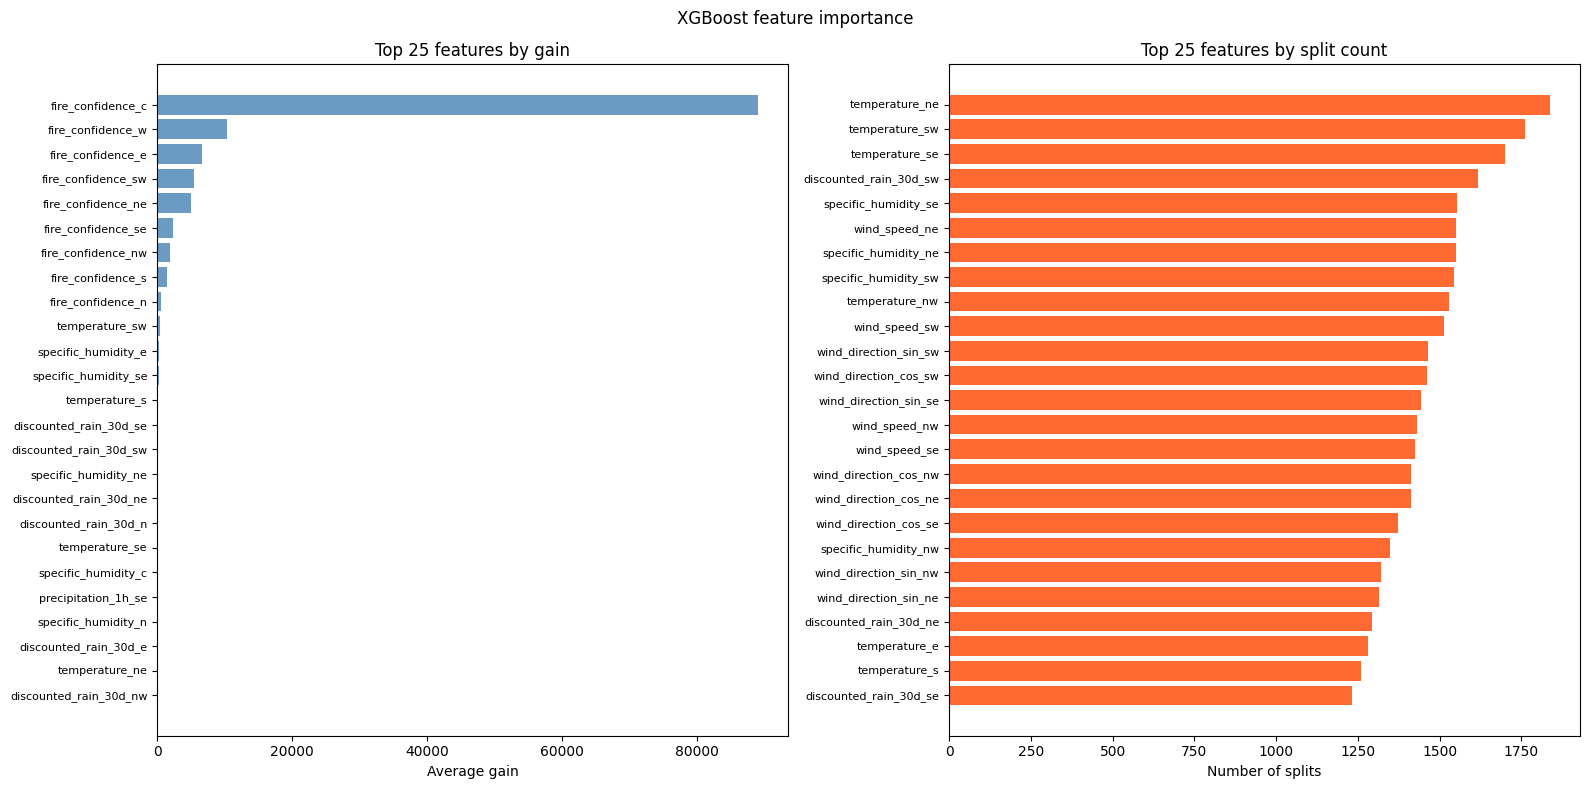


Top 15 by gain:
                         fire_confidence_c: 89061.8
                         fire_confidence_w: 10344.1
                         fire_confidence_e: 6638.9
                        fire_confidence_sw: 5418.3
                        fire_confidence_ne: 4959.3
                        fire_confidence_se: 2282.8
                        fire_confidence_nw: 1958.3
                         fire_confidence_s: 1454.2
                         fire_confidence_n: 633.3
                            temperature_sw: 375.6
                       specific_humidity_e: 235.3
                      specific_humidity_se: 198.0
                             temperature_s: 155.0
                    discounted_rain_30d_se: 154.1
                    discounted_rain_30d_sw: 152.7


In [11]:
if RUN_TRAINING_SECTION:
    importance_gain = xgb_model.get_booster().get_score(importance_type="gain")
    importance_weight = xgb_model.get_booster().get_score(importance_type="weight")

    feat_names = feature_schema.feature_names
    gain_vals = [(feat_names[int(k[1:])] if k.startswith("f") else k, v) for k, v in importance_gain.items()]
    gain_vals.sort(key=lambda x: x[1], reverse=True)

    weight_vals = [(feat_names[int(k[1:])] if k.startswith("f") else k, v) for k, v in importance_weight.items()]
    weight_vals.sort(key=lambda x: x[1], reverse=True)

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    top_n = 25
    names_g, vals_g = zip(*gain_vals[:top_n])
    axes[0].barh(range(len(names_g)), vals_g, color="steelblue", alpha=0.8)
    axes[0].set_yticks(range(len(names_g)))
    axes[0].set_yticklabels(names_g, fontsize=8)
    axes[0].invert_yaxis()
    axes[0].set_title(f"Top {top_n} features by gain")
    axes[0].set_xlabel("Average gain")

    names_w, vals_w = zip(*weight_vals[:top_n])
    axes[1].barh(range(len(names_w)), vals_w, color="orangered", alpha=0.8)
    axes[1].set_yticks(range(len(names_w)))
    axes[1].set_yticklabels(names_w, fontsize=8)
    axes[1].invert_yaxis()
    axes[1].set_title(f"Top {top_n} features by split count")
    axes[1].set_xlabel("Number of splits")

    fig.suptitle("XGBoost feature importance")
    fig.tight_layout()
    plt.show()

    print("\nTop 15 by gain:")
    for name, val in gain_vals[:15]:
        print(f"  {name:>40s}: {val:.1f}")

## 6) Evaluation on held-out test fires

Evaluate at fixed classification threshold on full (unsubsampled) test data.
No subsampling during evaluation — every sample is scored.

In [12]:
def evaluate_xgb(model, entries, repo_root, feature_schema, positive_threshold,
                 normalizer, prob_threshold, **kwargs):
    tp = fp = fn = tn = 0
    n_eval = 0
    for entry in entries:
        for _, _, X_hour, y_hour in iter_fire_hour_samples(
            entry, repo_root, feature_schema, positive_threshold, **kwargs,
        ):
            X_eval = normalizer.transform(X_hour).astype(np.float32, copy=False)
            y_eval = y_hour.astype(np.int32, copy=False)
            probs = model.predict_proba(X_eval)[:, 1]
            y_hat = (probs >= prob_threshold).astype(np.int32)
            tp += int(((y_hat == 1) & (y_eval == 1)).sum())
            fp += int(((y_hat == 1) & (y_eval == 0)).sum())
            fn += int(((y_hat == 0) & (y_eval == 1)).sum())
            tn += int(((y_hat == 0) & (y_eval == 0)).sum())
            n_eval += int(y_eval.shape[0])
    return {
        "count": n_eval,
        "accuracy_overall": (tp + tn) / max(n_eval, 1),
        "positive_accuracy": tp / max(tp + fn, 1),
        "negative_accuracy": tn / max(tn + fp, 1),
        "tp": tp, "fp": fp, "fn": fn, "tn": tn,
    }


metrics_test = None

if RUN_EVALUATION_SECTION:
    metrics_test = evaluate_xgb(
        xgb_model, test_fire_entries, REPO_ROOT, feature_schema, POSITIVE_THRESHOLD,
        normalizer, CLASSIFICATION_PROB_THRESHOLD, **ITERATION_KWARGS,
    )
    print(f"Test samples: {metrics_test['count']:,}")
    print(f"Overall accuracy: {metrics_test['accuracy_overall']:.4f}")
    print(f"Positive accuracy (recall): {metrics_test['positive_accuracy']:.4f}")
    print(f"Negative accuracy (specificity): {metrics_test['negative_accuracy']:.4f}")
    print(f"TP={metrics_test['tp']:,}  FP={metrics_test['fp']:,}  FN={metrics_test['fn']:,}  TN={metrics_test['tn']:,}")

Test samples: 43,895,169
Overall accuracy: 0.9940
Positive accuracy (recall): 0.8472
Negative accuracy (specificity): 0.9945
TP=106,726  FP=242,173  FN=19,243  TN=43,527,027


In [13]:
per_fire_results = []

if RUN_EVALUATION_SECTION and metrics_test is not None:
    print("Per-fire test metrics:")
    print(f"{'fire':>30s}  {'n':>10s}  {'prec':>6s}  {'rec':>6s}  {'f1':>6s}  {'TP':>7s}  {'FP':>7s}")
    print("-" * 85)

    for entry in test_fire_entries:
        fm = evaluate_xgb(
            xgb_model, [entry], REPO_ROOT, feature_schema, POSITIVE_THRESHOLD,
            normalizer, CLASSIFICATION_PROB_THRESHOLD, **ITERATION_KWARGS,
        )
        fm["fire_name"] = entry["fire_name"]
        prec = fm["tp"] / max(fm["tp"] + fm["fp"], 1)
        rec = fm["tp"] / max(fm["tp"] + fm["fn"], 1)
        f1 = 2 * prec * rec / max(prec + rec, 1e-8)
        fm["precision"] = prec
        fm["recall"] = rec
        fm["f1"] = f1
        per_fire_results.append(fm)
        print(f"{entry['fire_name']:>30s}  {fm['count']:>10,}  {prec:>6.4f}  {rec:>6.4f}  {f1:>6.4f}  {fm['tp']:>7,}  {fm['fp']:>7,}")

    per_fire_df = pd.DataFrame(per_fire_results)
    per_fire_df

Per-fire test metrics:
                          fire           n    prec     rec      f1       TP       FP
-------------------------------------------------------------------------------------
                August_Complex  28,169,573  0.3201  0.8432  0.4641   55,497  117,865
            Beckwourth_Complex   2,424,240  0.2585  0.8924  0.4008    9,406   26,985
         CZU_Lightning_Complex     348,812  0.3810  0.8468  0.5255    2,034    3,305
                         Dolan   1,996,224  0.2867  0.7858  0.4201    6,323   15,731
         LNU_Lightning_Complex   4,410,400  0.3536  0.8462  0.4987   11,609   21,226
                        McCash   4,816,516  0.2333  0.7853  0.3598    8,551   28,095
                        Walker     555,660  0.3024  0.8704  0.4489    2,895    6,677
                         Windy   1,173,744  0.3184  0.9269  0.4740   10,411   22,289


## 7) Precision-recall analysis

1. Train a temporary XGBoost on inner-train fires, sweep thresholds on validation fires, select best F1 threshold.
2. Transfer selected threshold to main model on test fires.
3. Sweep full test PR curve with main model.

In [14]:
def compute_xgb_pr_curve(model, entries, repo_root, feature_schema, positive_threshold,
                        normalizer, thresholds, **kwargs):
    tp_arr = np.zeros(len(thresholds), dtype=np.int64)
    fp_arr = np.zeros(len(thresholds), dtype=np.int64)
    total_pos = 0
    total_neg = 0
    for entry in entries:
        for _, _, X_hour, y_hour in iter_fire_hour_samples(
            entry, repo_root, feature_schema, positive_threshold, **kwargs,
        ):
            X_eval = normalizer.transform(X_hour).astype(np.float32, copy=False)
            y_eval = y_hour.astype(np.int32, copy=False)
            probs = model.predict_proba(X_eval)[:, 1]
            pos = y_eval == 1
            total_pos += int(pos.sum())
            total_neg += int((~pos).sum())
            pred = probs[:, None] >= thresholds[None, :]
            tp_arr += (pred & pos[:, None]).sum(axis=0).astype(np.int64)
            fp_arr += (pred & (~pos)[:, None]).sum(axis=0).astype(np.int64)
    fn_arr = total_pos - tp_arr
    precision = safe_divide(tp_arr, tp_arr + fp_arr, default=1.0)
    recall = safe_divide(tp_arr, np.full_like(tp_arr, total_pos), default=0.0)
    f1 = safe_divide(2.0 * precision * recall, precision + recall, default=0.0)
    df = pd.DataFrame({
        "threshold": thresholds, "precision": precision, "recall": recall,
        "f1": f1, "tp": tp_arr, "fp": fp_arr, "fn": fn_arr,
        "tn": total_neg - fp_arr,
    })
    best = df.iloc[int(df["f1"].idxmax())]
    baseline = total_pos / max(total_pos + total_neg, 1)
    return {"df": df, "best": best, "baseline": baseline}

inner-train fires: ['Antelope', 'Bobcat', 'Creek', 'Glass', 'July_Complex', 'Kincade', 'McFarland', 'Monument', 'Red_Salmon_Complex', 'River_Complex', 'SCU_Lightning_Complex', 'Slater_and_Devil', 'W-5_Cold_Springs', 'Zogg']
validation fires: ['Caldor', 'Dixie', 'KNP_Complex', 'North_Complex', 'SQF_Complex', 'Tamarack']

  positives: 152,346
  negatives: 1,636,524 / 54,491,072 (3.00% kept)
  total: 1,788,870 samples, 72 features
  positive rate: 8.5163%
  memory: 0.52 GB

Training validation XGBoost (scale_pos_weight=10.75)...
  best iteration: 499

Sweeping validation PR curve...

Best val threshold: 0.993
  precision=0.7948 recall=0.7613 f1=0.7777


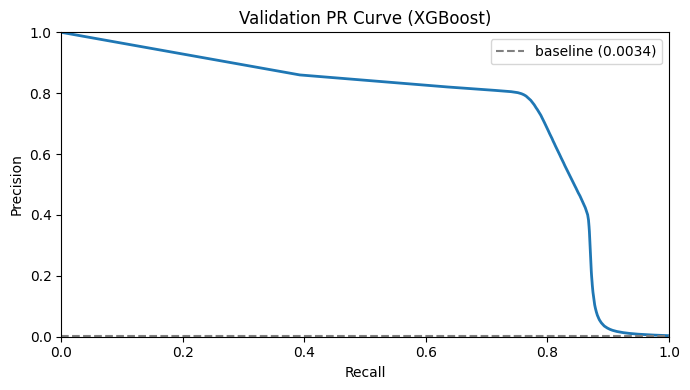

In [15]:
VAL_PR_THRESHOLDS = np.linspace(0.0, 1.0, 1001)
VAL_TUNED_THRESHOLD = None
val_pr_df = None
val_best = None
val_entries = []

if RUN_PR_SECTION:
    inner_train_entries, val_entries = split_validation_fire_entries(
        train_fire_entries, "auto", 0.30, 123,
    )
    print("inner-train fires:", [e["fire_name"] for e in inner_train_entries])
    print("validation fires:", [e["fire_name"] for e in val_entries])

    val_normalizer = fit_zscore_normalizer(
        inner_train_entries, REPO_ROOT, feature_schema, POSITIVE_THRESHOLD,
        enabled=NORMALIZE_FEATURES, **ITERATION_KWARGS,
    )

    print("\nCollecting validation model train data...")
    val_rng = np.random.default_rng(SUBSAMPLE_SEED)
    X_val_train, y_val_train, _ = collect_subsampled_data(
        inner_train_entries, REPO_ROOT, feature_schema, POSITIVE_THRESHOLD,
        val_normalizer, NEG_SUBSAMPLE_RATIO, val_rng, **ITERATION_KWARGS,
    )

    n_val_eval = int(X_val_train.shape[0] * EVAL_FRACTION)
    X_val_es = X_val_train[:n_val_eval]
    y_val_es = y_val_train[:n_val_eval]
    X_val_tr = X_val_train[n_val_eval:]
    y_val_tr = y_val_train[n_val_eval:]

    val_pos = int(y_val_tr.sum())
    val_neg = int(y_val_tr.shape[0] - val_pos)
    val_spw = val_neg / max(val_pos, 1)

    print(f"\nTraining validation XGBoost (scale_pos_weight={val_spw:.2f})...")
    val_model = xgb.XGBClassifier(
        n_estimators=N_ESTIMATORS,
        max_depth=MAX_DEPTH,
        learning_rate=LEARNING_RATE,
        subsample=SUBSAMPLE,
        colsample_bytree=COLSAMPLE_BYTREE,
        min_child_weight=MIN_CHILD_WEIGHT,
        reg_alpha=REG_ALPHA,
        reg_lambda=REG_LAMBDA,
        scale_pos_weight=val_spw,
        tree_method=TREE_METHOD,
        eval_metric="logloss",
        early_stopping_rounds=EARLY_STOPPING_ROUNDS,
        random_state=SEED,
        verbosity=0,
        n_jobs=-1,
    )
    val_model.fit(X_val_tr, y_val_tr, eval_set=[(X_val_es, y_val_es)], verbose=False)
    print(f"  best iteration: {val_model.best_iteration}")

    print("\nSweeping validation PR curve...")
    val_pr_result = compute_xgb_pr_curve(
        val_model, val_entries, REPO_ROOT, feature_schema, POSITIVE_THRESHOLD,
        val_normalizer, VAL_PR_THRESHOLDS, **ITERATION_KWARGS,
    )
    val_pr_df = val_pr_result["df"]
    val_best = val_pr_result["best"].to_dict()
    VAL_TUNED_THRESHOLD = float(val_pr_result["best"]["threshold"])

    print(f"\nBest val threshold: {VAL_TUNED_THRESHOLD:.3f}")
    print(f"  precision={val_best['precision']:.4f} recall={val_best['recall']:.4f} f1={val_best['f1']:.4f}")

    fig, ax = plt.subplots(figsize=(7, 4))
    plot_df = val_pr_df.sort_values("recall")
    ax.plot(plot_df["recall"], plot_df["precision"], linewidth=2)
    ax.axhline(val_pr_result["baseline"], ls="--", color="gray",
               label=f"baseline ({val_pr_result['baseline']:.4f})")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.set_title("Validation PR Curve (XGBoost)")
    ax.legend(); fig.tight_layout(); plt.show()

Val threshold (0.993) on test: prec=0.7608 rec=0.7240 f1=0.7419

Best test threshold: 0.991
  precision=0.7543 recall=0.7331 f1=0.7436


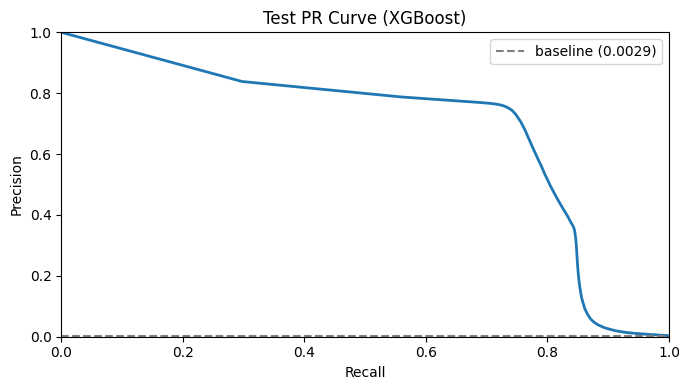

In [16]:
train_threshold_test_metrics = None
test_pr_df = None
test_pr_best = None
test_pr_baseline = None

if RUN_PR_SECTION:
    if VAL_TUNED_THRESHOLD is not None:
        train_threshold_test_metrics = evaluate_xgb(
            xgb_model, test_fire_entries, REPO_ROOT, feature_schema, POSITIVE_THRESHOLD,
            normalizer, VAL_TUNED_THRESHOLD, **ITERATION_KWARGS,
        )
        m = train_threshold_test_metrics
        prec = m["tp"] / max(m["tp"] + m["fp"], 1)
        rec = m["tp"] / max(m["tp"] + m["fn"], 1)
        f1_val = 2 * prec * rec / max(prec + rec, 1e-8)
        print(f"Val threshold ({VAL_TUNED_THRESHOLD:.3f}) on test: prec={prec:.4f} rec={rec:.4f} f1={f1_val:.4f}")

    TEST_PR_THRESHOLDS = np.linspace(0.0, 1.0, 1001)
    test_pr_result = compute_xgb_pr_curve(
        xgb_model, test_fire_entries, REPO_ROOT, feature_schema, POSITIVE_THRESHOLD,
        normalizer, TEST_PR_THRESHOLDS, **ITERATION_KWARGS,
    )
    test_pr_df = test_pr_result["df"]
    test_pr_best = test_pr_result["best"].to_dict()
    test_pr_baseline = float(test_pr_result["baseline"])

    print(f"\nBest test threshold: {test_pr_best['threshold']:.3f}")
    print(f"  precision={test_pr_best['precision']:.4f} recall={test_pr_best['recall']:.4f} f1={test_pr_best['f1']:.4f}")

    fig, ax = plt.subplots(figsize=(7, 4))
    plot_df = test_pr_df.sort_values("recall")
    ax.plot(plot_df["recall"], plot_df["precision"], linewidth=2)
    ax.axhline(test_pr_baseline, ls="--", color="gray",
               label=f"baseline ({test_pr_baseline:.4f})")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.set_title("Test PR Curve (XGBoost)")
    ax.legend(); fig.tight_layout(); plt.show()

In [17]:
if test_pr_df is not None:
    test_pr_df.sort_values("f1", ascending=False).head(20)

## 8) Report

Save configuration, architecture, and evaluation metrics to JSON.

In [18]:
def to_json_safe(obj):
    if isinstance(obj, dict):
        return {k: to_json_safe(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [to_json_safe(v) for v in obj]
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.bool_,)):
        return bool(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, pd.Series):
        return to_json_safe(obj.to_dict())
    return obj


if RUN_REPORT_SECTION:
    report = {
        "model": "xgboost_classifier",
        "target": "center_confidence_t_plus_1_binary",
        "fires_used": [e["fire_name"] for e in fire_entries],
        "train_fires": [e["fire_name"] for e in train_fire_entries],
        "test_fires": [e["fire_name"] for e in test_fire_entries],
        "validation_fires": [e["fire_name"] for e in val_entries],
        "thresholds": {
            "positive_confidence": POSITIVE_THRESHOLD,
            "classification_probability": CLASSIFICATION_PROB_THRESHOLD,
            "validation_selected_probability": VAL_TUNED_THRESHOLD,
        },
        "split": {
            "method": "fire_holdout",
            "train_fire_count": len(train_fire_entries),
            "test_fire_count": len(test_fire_entries),
            "train_fire_fraction_target": FIRE_TRAIN_FRACTION,
            "split_seed": FIRE_SPLIT_SEED,
        },
        "architecture": {
            "type": "xgboost_gradient_boosted_trees",
            "n_estimators": N_ESTIMATORS,
            "best_iteration": best_iteration if RUN_TRAINING_SECTION else None,
            "max_depth": MAX_DEPTH,
            "learning_rate": LEARNING_RATE,
            "subsample": SUBSAMPLE,
            "colsample_bytree": COLSAMPLE_BYTREE,
            "min_child_weight": MIN_CHILD_WEIGHT,
            "reg_alpha": REG_ALPHA,
            "reg_lambda": REG_LAMBDA,
            "tree_method": TREE_METHOD,
            "input_features": N_FEATURES,
        },
        "class_imbalance": {
            "neg_subsample_ratio": NEG_SUBSAMPLE_RATIO,
            "scale_pos_weight": spw if RUN_TRAINING_SECTION else None,
            "early_stopping_rounds": EARLY_STOPPING_ROUNDS,
        },
        "training": {
            "seed": SEED,
            "subsample_seed": SUBSAMPLE_SEED,
            "eval_fraction": EVAL_FRACTION,
            "train_samples_subsampled": int(X_train.shape[0]),
            "collect_stats": train_collect_stats,
        },
        "metrics_test_fixed_threshold": {
            "threshold": CLASSIFICATION_PROB_THRESHOLD,
            **(metrics_test if metrics_test else {}),
        },
        "per_fire_test_metrics": per_fire_results if per_fire_results else [],
        "validation_threshold_selection": {
            "best_threshold": VAL_TUNED_THRESHOLD,
            "best_metrics": val_best,
        },
        "train_threshold_transfer": train_threshold_test_metrics,
        "test_pr_curve": {
            "baseline": test_pr_baseline,
            "best": test_pr_best,
            "top_by_f1": (
                test_pr_df.sort_values("f1", ascending=False)
                .head(12).to_dict(orient="records")
                if test_pr_df is not None else []
            ),
        },
        "feature_importance_gain_top15": gain_vals[:15] if RUN_TRAINING_SECTION else [],
        "feature_order": feature_schema.feature_names,
        "data": {
            "total_samples": int(dataset_stats["total_samples"]) if dataset_stats else 0,
            "train_samples": int(dataset_stats["train"]["samples"]) if dataset_stats else 0,
            "test_samples": int(dataset_stats["test"]["samples"]) if dataset_stats else 0,
        },
    }

    report = to_json_safe(report)
    out_dir = REPO_ROOT / "data" / "analysis" / "xgb_fire_holdout"
    out_dir.mkdir(parents=True, exist_ok=True)
    report_path = out_dir / "report.json"
    with report_path.open("w", encoding="utf-8") as f:
        json.dump(report, f, indent=2)
    print("saved:", report_path)
    print("Report keys:", list(report.keys()))

saved: /Users/seanmay/Desktop/Current Projects/wildfire-prediction/data/analysis/xgb_fire_holdout/report.json
Report keys: ['model', 'target', 'fires_used', 'train_fires', 'test_fires', 'validation_fires', 'thresholds', 'split', 'architecture', 'class_imbalance', 'training', 'metrics_test_fixed_threshold', 'per_fire_test_metrics', 'validation_threshold_selection', 'train_threshold_transfer', 'test_pr_curve', 'feature_importance_gain_top15', 'feature_order', 'data']


## 9) Notes

- **Negative subsampling**: With ~100M training samples (99.7% negative), the full dataset doesn't fit in memory for XGBoost. Keeping all positives and 3% of negatives yields ~3.3M samples — enough for the tree ensemble to learn decision boundaries while remaining memory-efficient.
- **scale_pos_weight**: After subsampling, the positive rate is ~9%, still imbalanced. `scale_pos_weight` upweights positive-class gradients proportionally, equivalent to replicating positive samples.
- **Histogram-based splitting** (`tree_method="hist"`): Bins continuous features into 256 buckets before splitting. Much faster than exact greedy splitting on millions of samples, with negligible accuracy loss.
- **Early stopping**: A 10% holdout from the subsampled train data monitors validation logloss. Training stops after 30 rounds of no improvement to prevent overfitting.
- **Feature importance**: XGBoost's gain-based importance reveals which spatial/meteorological features drive predictions. Center-cell fire confidence is expected to dominate, but neighbor contributions and weather interactions are interpretable.
- **No temporal context**: Unlike the GRU model, XGBoost sees only the current hour's features (point-in-time). It cannot learn temporal trends like "temperature rising for 3 hours" without explicit feature engineering. This is a fundamental limitation compared to the RNN.
- **Normalization**: Z-score normalization is applied for consistency with other notebooks. XGBoost's tree splits are invariant to monotonic feature transforms, but normalization helps regularization (`reg_alpha`, `reg_lambda`) behave uniformly across features.
- Adjust `NEG_SUBSAMPLE_RATIO` to trade off between dataset size and training time/memory.